In [2]:
import csv
import random
import pandas as pd
import numpy as np
import time
from itertools import product
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from torchtuples.callbacks import EarlyStopping
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

import os
import torch
import torch.nn as nn
import torchtuples as tt

import lifelines
from pycox.models import CoxPH
from sklearn.metrics import brier_score_loss
from lifelines.utils import concordance_index
from sklearn.metrics import log_loss

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn_pandas import DataFrameMapper

In [3]:
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')

In [4]:
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42)

In [5]:
# det dummy
dummy_f = ['REGION','MARST', 'RACEA', 'USBORN', 'HSTATYR', 'ALCSTAT1', 'SMOKESTATUS2']
df_train = pd.get_dummies(df_train, columns=dummy_f, prefix=dummy_f).astype(int)
df_val = pd.get_dummies(df_val, columns=dummy_f, prefix=dummy_f).astype(int)
df_test = pd.get_dummies(df_test, columns=dummy_f, prefix=dummy_f).astype(int)

In [6]:
# list of columns to standardize
cols_stand = ['AGE', 'BMICALC', 'HRSLEEP']
              
cols_norm = ['FAMSIZE', 'EDUCREC1', 'POVERTY', 'FSRAWSCORE', 'ALC5UPYR', 'ALCAMT', 'ALCDAYSYR',
              'CIGSDAY', 'MOD10DMIN', 'MOD10FWK', 'VIG10DMIN', 'VIG10FWK', 'STRONGFWK', 'AEFFORT', 
              'AFEELINT1MO', 'AWORTHLESS', 'WRYMEDCST', 'WRYRET',
              'SEX', 'HINOTCOVE', 'HIPRIVATEE', 'HIMCAIDE', 'HIMCAREE', 'ARTHGLUPEV',
              'BLIND', 'CANCEREV', 'CHEARTDIEV', 'CPOXEV', 'DIABETICEV', 'EMPHYSEMEV',
              'HEARTATTEV', 'HEARTCONEV', 'HYPERTENEV', 'KIDNEYWKYR', 'LIVERCHRON',
              'LIVERCONYR', 'STROKEV']

# list of columns not to standardize
cols_leave = [col for col in df_train.columns if col not in cols_stand + cols_norm + ['TIMETOEVENT', 'MORTSTAT']]

# create mapper entries
standardize = [([col], StandardScaler()) for col in cols_stand]
normalize = [([col], MinMaxScaler()) for col in cols_norm]
leave = [(col, None) for col in cols_leave]

# combine into one mapper
x_mapper = DataFrameMapper(standardize + normalize + leave, df_out=False)

# prepare X matrices
x_train = df_train.drop(columns=['MORTSTAT', 'TIMETOEVENT'])
x_val = df_val.drop(columns=['MORTSTAT', 'TIMETOEVENT'])
x_test = df_test.drop(columns=['MORTSTAT', 'TIMETOEVENT'])

# transform
x_train = x_mapper.fit_transform(x_train).astype('float32')
x_val = x_mapper.transform(x_val).astype('float32')
x_test = x_mapper.transform(x_test).astype('float32')

In [7]:
get_target = lambda df: (df['TIMETOEVENT'].values, df['MORTSTAT'].values)

y_train = get_target(df_train)
y_val = get_target(df_val)
y_test = get_target(df_test)

In [8]:
# define adjusted loss funtions

In [9]:
def c_index_classification(y_true, y_pred_proba, times):
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    times = np.asarray(times)
    cc = dc = tp = 0

    n = len(y_true)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if times[i] < times[j] and y_true[i] == 1:
                if y_pred_proba[i] < y_pred_proba[j]:
                    cc += 1
                elif y_pred_proba[i] > y_pred_proba[j]:
                    dc += 1
                else:
                    tp += 1

        
    return (cc + 0.5 * tp) / (cc + dc + tp)

In [10]:
def ll3y(estimator, X, y_df):
    
    event_indicators = np.where((y_df["MORTSTAT"] == 1) & (y_df["TIMETOEVENT"] <= 3), 0, 1)
    estimator.compute_baseline_hazards()
    surv_f = estimator.predict_surv_df(X)
    surv_at_3 = surv_f.loc[3.0].values
    event_indicators = np.where((y_df["MORTSTAT"] == 1) & (y_df["TIMETOEVENT"] <= 3), 0, 1)

    try:
        ll = log_loss(event_indicators, surv_at_3)
        
        # check for NaNs in predictions
        if np.isnan(ll):
            print("NaNs in prediction — assigning score = -100")
            return -100.0
        
        # otherwise return log_loss
        return -ll
    
    except Exception as e:
        print(f"Error during scoring: {e} — assigning score = -100")
        return -100.0

In [11]:
def bs3y(estimator, X, y_df):
    
    event_indicators = np.where((y_df["MORTSTAT"] == 1) & (y_df["TIMETOEVENT"] <= 3), 0, 1)
    estimator.compute_baseline_hazards()
    surv_f = estimator.predict_surv_df(X)
    surv_at_3 = surv_f.loc[3.0].values
    event_indicators = np.where((y_df["MORTSTAT"] == 1) & (y_df["TIMETOEVENT"] <= 3), 0, 1)
    
    bs = brier_score_loss(event_indicators, surv_at_3)
       
    return -bs

In [12]:
# GridSearch DeepSurv

In [13]:
# ================================
# Step 0: set seeds for reproducibility
# ================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ================================
# step 1: define parameter grid
# ================================

param_grid = {'batch_size': [300, 500, 800],
              'epochs': [20, 40, 60], 
              'lr': [0.001, 0.005, 0.1],
              'dropout': [0.0, 0.1, 0.2],
              'num_nodes': [[32, 16], [32], [16]]}

param_combos = list(product(param_grid['batch_size'], param_grid['epochs'], param_grid['lr'], param_grid['dropout'], param_grid['num_nodes']))

# ================================
# step 2: compute cross-validation loss for each combination of hyperparatmers
# ================================

# unpack y_train tuple: (durations, events)
T_all, E_all = y_train

n_splits = 4
results_ll = []
results_bs = []

for i, (batch_size, epochs, lr, dropout, num_nodes) in enumerate(param_combos):
    print(f"\n=== Grid {i+1}/{len(param_combos)}:  batch_size={batch_size},  epochs={epochs}, lr={lr}, dropout={dropout}, nodes={num_nodes} ===")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores_ll = []
    scores_bs = []

    for fold, (train_idx, tst_idx) in enumerate(kf.split(x_train)):
        print(f"  Fold {fold + 1}/{n_splits}")

        x_tr, x_tst = x_train[train_idx], x_train[tst_idx]
        T_tr, T_tst = T_all[train_idx], T_all[tst_idx]
        E_tr, E_tst = E_all[train_idx], E_all[tst_idx]

        net = tt.practical.MLPVanilla(in_features=x_tr.shape[1], num_nodes=num_nodes, out_features=1,
                                      activation=nn.ReLU, dropout=dropout)    
      
        optimizer = tt.optim.Adam(lr=lr)
        model = CoxPH(net, optimizer)
         
        checkpoint_path = 'best_model.pt'

        if os.path.exists(checkpoint_path):
            os.remove(checkpoint_path)

        callbacks = [EarlyStopping(patience=10, file_path=checkpoint_path)]
        model.fit(x_tr, (T_tr, E_tr), batch_size=batch_size, epochs=epochs, val_data=(x_val, y_val), shuffle=True,
                  verbose=False, callbacks=callbacks)
        
        y_tst = pd.DataFrame({"TIMETOEVENT": T_tst,"MORTSTAT": E_tst}).reset_index(drop=True)
        score_ll = ll3y(model, x_tst, y_tst)
        scores_ll.append(score_ll)
        score_bs = bs3y(model, x_tst, y_tst)
        scores_bs.append(score_bs)

        print(f"    LL3Y is: {-score_ll:.4f}")
        print(f"    BS3Y is: {-score_bs:.4f}")

    mean_score_ll = np.mean(scores_ll)  
    mean_score_bs = np.mean(scores_bs)
 

    results_ll.append({'batch_size': batch_size, 'epochs': epochs, 'lr': lr, 'dropout': dropout, 'num_nodes': str(num_nodes),'mean_neg_ll': mean_score_ll})

    results_bs.append({'batch_size': batch_size, 'epochs': epochs, 'lr': lr, 'dropout': dropout, 'num_nodes': str(num_nodes),'mean_neg_bs': mean_score_bs})


=== Grid 1/243:  batch_size=300,  epochs=20, lr=0.001, dropout=0.0, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1138
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1121
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1196
    BS3Y is: 0.0316
  Fold 4/4
    LL3Y is: 0.1097
    BS3Y is: 0.0284

=== Grid 2/243:  batch_size=300,  epochs=20, lr=0.001, dropout=0.0, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1144
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1140
    BS3Y is: 0.0304
  Fold 3/4
    LL3Y is: 0.1205
    BS3Y is: 0.0319
  Fold 4/4
    LL3Y is: 0.1082
    BS3Y is: 0.0282

=== Grid 3/243:  batch_size=300,  epochs=20, lr=0.001, dropout=0.0, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1139
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1117
    BS3Y is: 0.0299
  Fold 3/4
    LL3Y is: 0.1201
    BS3Y is: 0.0317
  Fold 4/4
    LL3Y is: 0.1083
    BS3Y is: 0.0282

=== Grid 4/243:  batch_size=300,  epochs=20, lr=0.001, dropout=0.1, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1140
    BS3Y is: 

C:\ProgramData\anaconda3\Lib\site-packages\pycox\models\cox.py:231: RuntimeWarning: overflow encountered in exp
  .assign(expg=np.exp(self.predict(input, batch_size, True, eval_, num_workers=num_workers)))
C:\ProgramData\anaconda3\Lib\site-packages\pycox\models\cox.py:231: RuntimeWarning: overflow encountered in exp
  .assign(expg=np.exp(self.predict(input, batch_size, True, eval_, num_workers=num_workers)))


    LL3Y is: 1.4292
    BS3Y is: 0.0397
  Fold 4/4
    LL3Y is: 0.1098
    BS3Y is: 0.0287

=== Grid 27/243:  batch_size=300,  epochs=20, lr=0.1, dropout=0.2, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1141
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1122
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.2110
    BS3Y is: 0.0389
  Fold 4/4
    LL3Y is: 0.1104
    BS3Y is: 0.0289

=== Grid 28/243:  batch_size=300,  epochs=40, lr=0.001, dropout=0.0, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1149
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1118
    BS3Y is: 0.0298
  Fold 3/4
    LL3Y is: 0.1199
    BS3Y is: 0.0317
  Fold 4/4
    LL3Y is: 0.1081
    BS3Y is: 0.0282

=== Grid 29/243:  batch_size=300,  epochs=40, lr=0.001, dropout=0.0, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1142
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1121
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1197
    BS3Y is: 0.0315
  Fold 4/4
    LL3Y is: 0.1088
    BS3Y is: 0.0284

=== Grid 30/243:  batch_size=300,  epoc

    LL3Y is: 0.1146
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1125
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1209
    BS3Y is: 0.0317
  Fold 4/4
    LL3Y is: 0.1108
    BS3Y is: 0.0287

=== Grid 56/243:  batch_size=300,  epochs=60, lr=0.001, dropout=0.0, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1136
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1122
    BS3Y is: 0.0299
  Fold 3/4
    LL3Y is: 0.1206
    BS3Y is: 0.0319
  Fold 4/4
    LL3Y is: 0.1092
    BS3Y is: 0.0285

=== Grid 57/243:  batch_size=300,  epochs=60, lr=0.001, dropout=0.0, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1141
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1121
    BS3Y is: 0.0299
  Fold 3/4
    LL3Y is: 0.1212
    BS3Y is: 0.0319
  Fold 4/4
    LL3Y is: 0.1111
    BS3Y is: 0.0285

=== Grid 58/243:  batch_size=300,  epochs=60, lr=0.001, dropout=0.1, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1139
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1117
    BS3Y is: 0.0299
  Fold 3/4
    LL3Y is: 0.1185
    BS3

    LL3Y is: 0.1191
    BS3Y is: 0.0314
  Fold 4/4
    LL3Y is: 0.1085
    BS3Y is: 0.0283

=== Grid 84/243:  batch_size=500,  epochs=20, lr=0.001, dropout=0.0, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1147
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1118
    BS3Y is: 0.0298
  Fold 3/4
    LL3Y is: 0.1200
    BS3Y is: 0.0316
  Fold 4/4
    LL3Y is: 0.1089
    BS3Y is: 0.0284

=== Grid 85/243:  batch_size=500,  epochs=20, lr=0.001, dropout=0.1, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1138
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1305
    BS3Y is: 0.0329
  Fold 3/4
    LL3Y is: 0.1202
    BS3Y is: 0.0319
  Fold 4/4
    LL3Y is: 0.1086
    BS3Y is: 0.0283

=== Grid 86/243:  batch_size=500,  epochs=20, lr=0.001, dropout=0.1, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1137
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1131
    BS3Y is: 0.0301
  Fold 3/4
    LL3Y is: 0.1202
    BS3Y is: 0.0317
  Fold 4/4
    LL3Y is: 0.1082
    BS3Y is: 0.0281

=== Grid 87/243:  batch_size=500,  ep

    LL3Y is: 0.1138
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1129
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1203
    BS3Y is: 0.0317
  Fold 4/4
    LL3Y is: 0.1090
    BS3Y is: 0.0284

=== Grid 113/243:  batch_size=500,  epochs=40, lr=0.001, dropout=0.1, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1132
    BS3Y is: 0.0297
  Fold 2/4
    LL3Y is: 0.1121
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1195
    BS3Y is: 0.0316
  Fold 4/4
    LL3Y is: 0.1096
    BS3Y is: 0.0285

=== Grid 114/243:  batch_size=500,  epochs=40, lr=0.001, dropout=0.1, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1137
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1117
    BS3Y is: 0.0299
  Fold 3/4
    LL3Y is: 0.1194
    BS3Y is: 0.0316
  Fold 4/4
    LL3Y is: 0.1087
    BS3Y is: 0.0284

=== Grid 115/243:  batch_size=500,  epochs=40, lr=0.001, dropout=0.2, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1133
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1126
    BS3Y is: 0.0299
  Fold 3/4
    LL3Y is: 0.1190
    

    LL3Y is: 0.1194
    BS3Y is: 0.0316
  Fold 4/4
    LL3Y is: 0.1088
    BS3Y is: 0.0283

=== Grid 141/243:  batch_size=500,  epochs=60, lr=0.001, dropout=0.1, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1135
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1122
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1192
    BS3Y is: 0.0317
  Fold 4/4
    LL3Y is: 0.1083
    BS3Y is: 0.0282

=== Grid 142/243:  batch_size=500,  epochs=60, lr=0.001, dropout=0.2, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1133
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1113
    BS3Y is: 0.0297
  Fold 3/4
    LL3Y is: 0.1202
    BS3Y is: 0.0319
  Fold 4/4
    LL3Y is: 0.1105
    BS3Y is: 0.0287

=== Grid 143/243:  batch_size=500,  epochs=60, lr=0.001, dropout=0.2, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1136
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1118
    BS3Y is: 0.0298
  Fold 3/4
    LL3Y is: 0.1188
    BS3Y is: 0.0315
  Fold 4/4
    LL3Y is: 0.1095
    BS3Y is: 0.0286

=== Grid 144/243:  batch_size=500,

    LL3Y is: 0.1242
    BS3Y is: 0.0316
  Fold 2/4
    LL3Y is: 0.1150
    BS3Y is: 0.0304
  Fold 3/4
    LL3Y is: 0.1687
    BS3Y is: 0.0382
  Fold 4/4
    LL3Y is: 0.1171
    BS3Y is: 0.0299

=== Grid 170/243:  batch_size=800,  epochs=20, lr=0.001, dropout=0.2, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1138
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1122
    BS3Y is: 0.0298
  Fold 3/4
    LL3Y is: 0.1191
    BS3Y is: 0.0316
  Fold 4/4
    LL3Y is: 0.1141
    BS3Y is: 0.0294

=== Grid 171/243:  batch_size=800,  epochs=20, lr=0.001, dropout=0.2, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1535
    BS3Y is: 0.0347
  Fold 2/4
    LL3Y is: 0.1624
    BS3Y is: 0.0358
  Fold 3/4
    LL3Y is: 0.1690
    BS3Y is: 0.0382
  Fold 4/4
    LL3Y is: 0.1107
    BS3Y is: 0.0288

=== Grid 172/243:  batch_size=800,  epochs=20, lr=0.005, dropout=0.0, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1137
    BS3Y is: 0.0299
  Fold 2/4
    LL3Y is: 0.1123
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1677
    

    LL3Y is: 0.1234
    BS3Y is: 0.0325
  Fold 4/4
    LL3Y is: 0.1102
    BS3Y is: 0.0288

=== Grid 198/243:  batch_size=800,  epochs=40, lr=0.001, dropout=0.2, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1161
    BS3Y is: 0.0303
  Fold 2/4
    LL3Y is: 0.1140
    BS3Y is: 0.0302
  Fold 3/4
    LL3Y is: 0.1215
    BS3Y is: 0.0321
  Fold 4/4
    LL3Y is: 0.1109
    BS3Y is: 0.0288

=== Grid 199/243:  batch_size=800,  epochs=40, lr=0.005, dropout=0.0, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1145
    BS3Y is: 0.0301
  Fold 2/4
    LL3Y is: 0.1118
    BS3Y is: 0.0299
  Fold 3/4
    LL3Y is: 0.1695
    BS3Y is: 0.0382
  Fold 4/4
    LL3Y is: 0.1099
    BS3Y is: 0.0286

=== Grid 200/243:  batch_size=800,  epochs=40, lr=0.005, dropout=0.0, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1142
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1126
    BS3Y is: 0.0301
  Fold 3/4
    LL3Y is: 0.1196
    BS3Y is: 0.0317
  Fold 4/4
    LL3Y is: 0.1084
    BS3Y is: 0.0284

=== Grid 201/243:  batch_size=800,

    LL3Y is: 0.1135
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1129
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1684
    BS3Y is: 0.0382
  Fold 4/4
    LL3Y is: 0.1090
    BS3Y is: 0.0283

=== Grid 227/243:  batch_size=800,  epochs=60, lr=0.005, dropout=0.0, nodes=[32] ===
  Fold 1/4
    LL3Y is: 0.1137
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1127
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1197
    BS3Y is: 0.0316
  Fold 4/4
    LL3Y is: 0.1506
    BS3Y is: 0.0338

=== Grid 228/243:  batch_size=800,  epochs=60, lr=0.005, dropout=0.0, nodes=[16] ===
  Fold 1/4
    LL3Y is: 0.1571
    BS3Y is: 0.0350
  Fold 2/4
    LL3Y is: 0.1113
    BS3Y is: 0.0298
  Fold 3/4
    LL3Y is: 0.1695
    BS3Y is: 0.0382
  Fold 4/4
    LL3Y is: 0.1098
    BS3Y is: 0.0288

=== Grid 229/243:  batch_size=800,  epochs=60, lr=0.005, dropout=0.1, nodes=[32, 16] ===
  Fold 1/4
    LL3Y is: 0.1136
    BS3Y is: 0.0300
  Fold 2/4
    LL3Y is: 0.1121
    BS3Y is: 0.0300
  Fold 3/4
    LL3Y is: 0.1203
    

In [14]:
# report best result in terms of log loss

results_ll_df = pd.DataFrame(results_ll)
results_ll_df['ll3y'] = - results_ll_df['mean_neg_ll']

print("\n=== All Results ===")
print(results_ll_df.sort_values(by='mean_neg_ll', ascending=False).to_string(index=False))


=== All Results ===
 batch_size  epochs    lr  dropout num_nodes  mean_neg_ll     ll3y
        800      60 0.005      0.2      [32]    -0.112885 0.112885
        500      60 0.001      0.2      [16]    -0.112925 0.112925
        500      20 0.005      0.2      [16]    -0.112947 0.112947
        500      20 0.001      0.0      [32]    -0.113080 0.113080
        300      60 0.005      0.2      [32]    -0.113116 0.113116
        300      60 0.001      0.1  [32, 16]    -0.113145 0.113145
        300      40 0.005      0.0      [16]    -0.113161 0.113161
        300      60 0.001      0.2      [32]    -0.113167 0.113167
        500      60 0.005      0.1      [32]    -0.113167 0.113167
        500      60 0.005      0.2      [16]    -0.113205 0.113205
        300      40 0.001      0.2      [32]    -0.113250 0.113250
        500      40 0.001      0.2      [16]    -0.113255 0.113255
        500      60 0.005      0.0      [32]    -0.113262 0.113262
        500      60 0.005      0.1  [32, 

In [15]:
#_________________________________________________________________________________________________________________________

In [16]:
#_________________________________________________________________________________________________________________________

In [17]:
# DeepS1L

In [18]:
# ================================
# step 0: set seeds for reproducibility
# ================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ================================
# step 1: define the network
# ================================

in_features = x_train.shape[1]
net = tt.practical.MLPVanilla(in_features, [32], 1, activation=nn.ReLU, dropout=0.2)

# ================================
# step 3: define model and optimizer
# ================================

optimizer = tt.optim.Adam(lr=0.005)  
model = CoxPH(net, optimizer)

# ================================
# step 4: training setup 
# ================================

batch_size = 800
epochs = 60

# remove old checkpoints
if os.path.exists('best_model.pt'):
    os.remove('best_model.pt')

# ================================
# step 5: fit a model
# ================================

callbacks = [EarlyStopping(patience=10, file_path=None)]
log = model.fit(x_train, y_train, batch_size, epochs, val_data=(x_val, y_val), shuffle=False, callbacks=callbacks)

0:	[0s / 0s],		train_loss: 5.3535,	val_loss: 6.2960
1:	[0s / 0s],		train_loss: 5.1523,	val_loss: 6.2909
2:	[0s / 0s],		train_loss: 5.1310,	val_loss: 6.2877
3:	[0s / 1s],		train_loss: 5.1051,	val_loss: 6.2759
4:	[0s / 1s],		train_loss: 5.0965,	val_loss: 6.2976
5:	[0s / 1s],		train_loss: 5.0779,	val_loss: 6.2893
6:	[0s / 1s],		train_loss: 5.0670,	val_loss: 6.2724
7:	[0s / 2s],		train_loss: 5.0617,	val_loss: 6.2806
8:	[0s / 2s],		train_loss: 5.0487,	val_loss: 6.2808
9:	[0s / 2s],		train_loss: 5.0377,	val_loss: 6.2584
10:	[0s / 3s],		train_loss: 5.0254,	val_loss: 6.2869
11:	[0s / 3s],		train_loss: 5.0205,	val_loss: 6.2962
12:	[0s / 3s],		train_loss: 5.0160,	val_loss: 6.2923
13:	[0s / 3s],		train_loss: 5.0160,	val_loss: 6.2873
14:	[0s / 4s],		train_loss: 5.0077,	val_loss: 6.2824
15:	[0s / 4s],		train_loss: 5.0062,	val_loss: 6.2622
16:	[0s / 4s],		train_loss: 4.9977,	val_loss: 6.3055
17:	[0s / 4s],		train_loss: 4.9933,	val_loss: 6.2686
18:	[0s / 5s],		train_loss: 4.9916,	val_loss: 6.2774
19:

<Axes: >

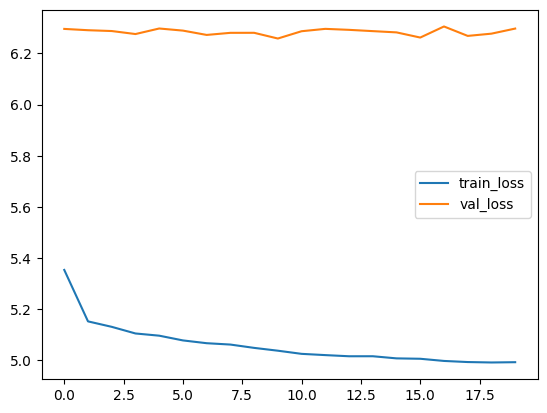

In [19]:
log.plot()

In [20]:
# compute baseline hazard
model.compute_baseline_hazards()

surv_train = model.predict_surv_df(x_train)  
surv_at_3_train = surv_train.loc[3.0]        
surv_test = model.predict_surv_df(x_test)  
surv_at_3_test = surv_test.loc[3.0]       

# get 3-year event status based on TIMETOEVENT and MORTSTAT
status_3y_train = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 0, 1)
status_3y_test = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 0, 1)

surv_f = model.predict_surv_df(x_train)
surv_at_3 = surv_f.loc[3.0].values
#c_is =  c_index_classification(df_train["MORTSTAT"], surv_at_3, df_train['TIMETOEVENT'])

print(f'log-loss is: {log_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'log-loss os: {log_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'BS is: {brier_score_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'BS os: {brier_score_loss(status_3y_test, surv_at_3_test):.4f}')
#print(f'C is:, {c_is:.4f}')

log-loss is: 0.1090
log-loss os: 0.1090
BS is: 0.0290
BS os: 0.0290


In [21]:
# DeepS2L

In [22]:
# ================================
# step 0: set seeds for reproducibility
# ================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ================================
# step 2: define the network
# ================================

in_features = x_train.shape[1]
net = tt.practical.MLPVanilla(in_features, [16], 1, activation=nn.ReLU, dropout=0.2)

# ================================
# step 3: model and optimizer
# ================================

optimizer = tt.optim.Adam(lr=0.001)  
model = CoxPH(net, optimizer)

# ================================
# step 4: training setup 
# ================================

batch_size = 500
epochs = 60

# remove old checkpoints
if os.path.exists('best_model.pt'):
    os.remove('best_model.pt')

# ================================
# step 5: fit a model
# ================================

callbacks = [EarlyStopping(patience=10, file_path=None)]
log = model.fit(x_train, y_train, batch_size, epochs, val_data=(x_val, y_val), shuffle=False, callbacks=callbacks)

0:	[0s / 0s],		train_loss: 5.1468,	val_loss: 6.5154
1:	[0s / 0s],		train_loss: 4.7593,	val_loss: 6.3808
2:	[0s / 1s],		train_loss: 4.7029,	val_loss: 6.3414
3:	[0s / 1s],		train_loss: 4.6951,	val_loss: 6.3212
4:	[0s / 1s],		train_loss: 4.6776,	val_loss: 6.3136
5:	[0s / 2s],		train_loss: 4.6605,	val_loss: 6.2993
6:	[0s / 2s],		train_loss: 4.6463,	val_loss: 6.2976
7:	[0s / 2s],		train_loss: 4.6486,	val_loss: 6.2996
8:	[0s / 3s],		train_loss: 4.6448,	val_loss: 6.2992
9:	[0s / 3s],		train_loss: 4.6410,	val_loss: 6.3008
10:	[0s / 4s],		train_loss: 4.6358,	val_loss: 6.3038
11:	[0s / 4s],		train_loss: 4.6194,	val_loss: 6.3140
12:	[0s / 4s],		train_loss: 4.6179,	val_loss: 6.3023
13:	[0s / 5s],		train_loss: 4.6129,	val_loss: 6.3070
14:	[0s / 5s],		train_loss: 4.6168,	val_loss: 6.3126
15:	[0s / 6s],		train_loss: 4.6052,	val_loss: 6.3249
16:	[0s / 6s],		train_loss: 4.6044,	val_loss: 6.3179


<Axes: >

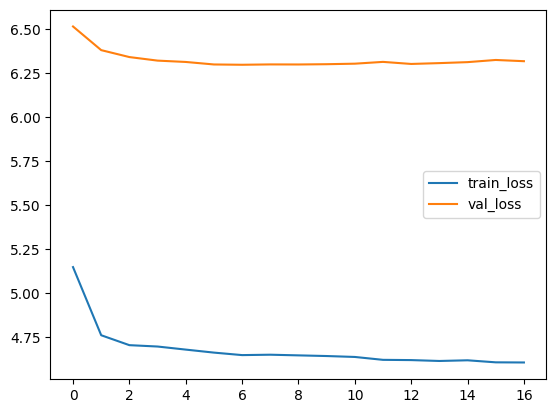

In [23]:
log.plot()

In [24]:
# compute baseline hazard
model.compute_baseline_hazards()

surv_train = model.predict_surv_df(x_train)  
surv_at_3_train = surv_train.loc[3.0]        
surv_test = model.predict_surv_df(x_test)  
surv_at_3_test = surv_test.loc[3.0]       

# get 3-year event status based on TIMETOEVENT and MORTSTAT
status_3y_train = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 0, 1)
status_3y_test = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 0, 1)

surv_f = model.predict_surv_df(x_train)
surv_at_3 = surv_f.loc[3.0].values
c_is =  c_index_classification(df_train["MORTSTAT"], surv_at_3, df_train['TIMETOEVENT'])

print(f'log-loss is: {log_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'log-loss os: {log_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'BS is: {brier_score_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'BS os: {brier_score_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'C is:, {c_is:.4f}')

log-loss is: 0.1121
log-loss os: 0.1102
BS is: 0.0297
BS os: 0.0293
C is:, 0.8897


In [25]:
# DeepS3L

In [26]:
# ================================
# step 0: set seeds for reproducibility
# ================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ================================
# step 2: define the network
# ================================

in_features = x_train.shape[1]
net = tt.practical.MLPVanilla(in_features, [32], 1, activation=nn.ReLU, dropout=0.2)

# ================================
# step 3: model and optimizer
# ================================

optimizer = tt.optim.Adam(lr=0.005)  
model = CoxPH(net, optimizer)

# ================================
# step 4: training setup 
# ================================

batch_size = 300
epochs = 60

# remove old checkpoints
if os.path.exists('best_model.pt'):
    os.remove('best_model.pt')

# ================================
# step 5: fit a model
# ================================

callbacks = [EarlyStopping(patience=10, file_path=None)]
log = model.fit(x_train, y_train, batch_size, epochs, val_data=(x_val, y_val), shuffle=False, callbacks=callbacks)

0:	[0s / 0s],		train_loss: 4.2744,	val_loss: 6.3154
1:	[0s / 1s],		train_loss: 4.1599,	val_loss: 6.3105
2:	[0s / 1s],		train_loss: 4.1370,	val_loss: 6.3272
3:	[0s / 2s],		train_loss: 4.1194,	val_loss: 6.3263
4:	[0s / 2s],		train_loss: 4.0951,	val_loss: 6.3046
5:	[0s / 3s],		train_loss: 4.0845,	val_loss: 6.2891
6:	[0s / 4s],		train_loss: 4.0729,	val_loss: 6.3080
7:	[0s / 5s],		train_loss: 4.0689,	val_loss: 6.3345
8:	[0s / 5s],		train_loss: 4.0642,	val_loss: 6.2858
9:	[0s / 6s],		train_loss: 4.0566,	val_loss: 6.3027
10:	[0s / 7s],		train_loss: 4.0595,	val_loss: 6.3039
11:	[0s / 7s],		train_loss: 4.0430,	val_loss: 6.2924
12:	[0s / 8s],		train_loss: 4.0423,	val_loss: 6.2859
13:	[0s / 9s],		train_loss: 4.0351,	val_loss: 6.2992
14:	[0s / 9s],		train_loss: 4.0339,	val_loss: 6.3176
15:	[0s / 10s],		train_loss: 4.0380,	val_loss: 6.3041
16:	[0s / 11s],		train_loss: 4.0316,	val_loss: 6.3159
17:	[0s / 11s],		train_loss: 4.0411,	val_loss: 6.3131
18:	[0s / 12s],		train_loss: 4.0239,	val_loss: 6.3034

<Axes: >

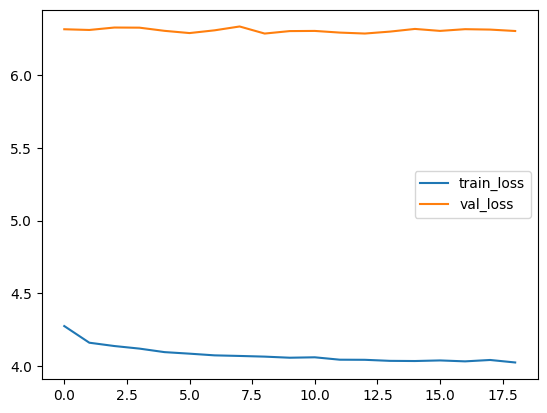

In [27]:
log.plot()

In [28]:
# compute baseline hazard
model.compute_baseline_hazards()

surv_train = model.predict_surv_df(x_train)  
surv_at_3_train = surv_train.loc[3.0]        
surv_test = model.predict_surv_df(x_test)  
surv_at_3_test = surv_test.loc[3.0]       

# get 3-year event status based on TIMETOEVENT and MORTSTAT
status_3y_train = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 0, 1)
status_3y_test = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 0, 1)

surv_f = model.predict_surv_df(x_train)
surv_at_3 = surv_f.loc[3.0].values
c_is =  c_index_classification(df_train["MORTSTAT"], surv_at_3, df_train['TIMETOEVENT'])

print(f'log-loss is: {log_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'log-loss os: {log_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'BS is: {brier_score_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'BS os: {brier_score_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'C is:, {c_is:.4f}')

log-loss is: 0.1101
log-loss os: 0.1099
BS is: 0.0293
BS os: 0.0293
C is:, 0.8956


In [29]:
#_________________________________________________________________________________________________________________________

In [30]:
# report best result based on brier score
results_bs_df = pd.DataFrame(results_bs)
results_bs_df['bs3y'] = - results_bs_df['mean_neg_bs']

print("\n=== All Results ===")
print(results_bs_df.sort_values(by='mean_neg_bs', ascending=False).to_string(index=False))


=== All Results ===
 batch_size  epochs    lr  dropout num_nodes  mean_neg_bs     bs3y
        500      60 0.001      0.2      [16]    -0.029839 0.029839
        500      20 0.001      0.0      [32]    -0.029857 0.029857
        500      20 0.005      0.2      [16]    -0.029860 0.029860
        800      60 0.005      0.2      [32]    -0.029861 0.029861
        500      60 0.005      0.1  [32, 16]    -0.029879 0.029879
        300      40 0.005      0.0      [16]    -0.029885 0.029885
        500      60 0.005      0.1      [32]    -0.029886 0.029886
        300      60 0.005      0.2      [32]    -0.029894 0.029894
        300      60 0.001      0.1  [32, 16]    -0.029895 0.029895
        500      60 0.005      0.0      [32]    -0.029899 0.029899
        300      60 0.001      0.2      [32]    -0.029901 0.029901
        500      40 0.001      0.0      [16]    -0.029903 0.029903
        500      60 0.100      0.0  [32, 16]    -0.029913 0.029913
        500      40 0.001      0.2      [

In [31]:
# DeepS1B

In [32]:
# ================================
# step 0: set seeds for reproducibility
# ================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ================================
# step 2: define the network
# ================================
in_features = x_train.shape[1]
net = tt.practical.MLPVanilla(in_features, [16], 1, activation=nn.ReLU, dropout=0.2)

# ================================
# step 3: model and optimizer
# ================================

optimizer = tt.optim.Adam(lr=0.001)  
model = CoxPH(net, optimizer)

# ================================
# step 4: training setup   
# ================================

batch_size = 500
epochs = 60

# remove old checkpoints
if os.path.exists('best_model.pt'):
    os.remove('best_model.pt')

# ================================
# step 5: fit a model
# ================================

callbacks = [EarlyStopping(patience=10, file_path=None)]
log = model.fit(x_train, y_train, batch_size, epochs, val_data=(x_val, y_val), shuffle=False, callbacks=callbacks)

0:	[0s / 0s],		train_loss: 5.1468,	val_loss: 6.5154
1:	[0s / 0s],		train_loss: 4.7593,	val_loss: 6.3808
2:	[0s / 1s],		train_loss: 4.7029,	val_loss: 6.3414
3:	[0s / 1s],		train_loss: 4.6951,	val_loss: 6.3212
4:	[0s / 1s],		train_loss: 4.6776,	val_loss: 6.3136
5:	[0s / 2s],		train_loss: 4.6605,	val_loss: 6.2993
6:	[0s / 2s],		train_loss: 4.6463,	val_loss: 6.2976
7:	[0s / 2s],		train_loss: 4.6486,	val_loss: 6.2996
8:	[0s / 3s],		train_loss: 4.6448,	val_loss: 6.2992
9:	[0s / 3s],		train_loss: 4.6410,	val_loss: 6.3008
10:	[0s / 4s],		train_loss: 4.6358,	val_loss: 6.3038
11:	[0s / 4s],		train_loss: 4.6194,	val_loss: 6.3140
12:	[0s / 4s],		train_loss: 4.6179,	val_loss: 6.3023
13:	[0s / 5s],		train_loss: 4.6129,	val_loss: 6.3070
14:	[0s / 6s],		train_loss: 4.6168,	val_loss: 6.3126
15:	[0s / 6s],		train_loss: 4.6052,	val_loss: 6.3249
16:	[0s / 7s],		train_loss: 4.6044,	val_loss: 6.3179


<Axes: >

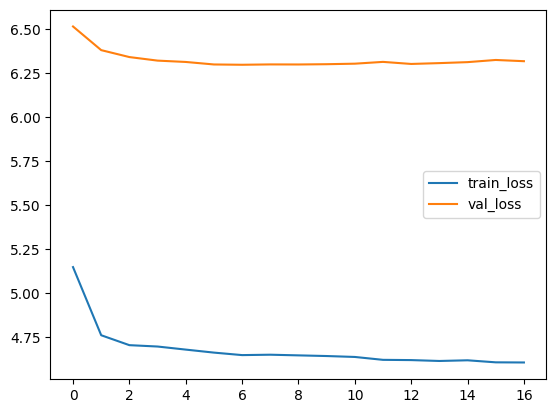

In [33]:
log.plot()

In [34]:
# compute baseline hazard
model.compute_baseline_hazards()

surv_train = model.predict_surv_df(x_train)  
surv_at_3_train = surv_train.loc[3.0]        
surv_test = model.predict_surv_df(x_test)  
surv_at_3_test = surv_test.loc[3.0]       

# get 3-year event status based on TIMETOEVENT and MORTSTAT
status_3y_train = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 0, 1)
status_3y_test = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 0, 1)

surv_f = model.predict_surv_df(x_train)
surv_at_3 = surv_f.loc[3.0].values
c_is =  c_index_classification(df_train["MORTSTAT"], surv_at_3, df_train['TIMETOEVENT'])

print(f'log-loss is: {log_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'log-loss os: {log_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'BS is: {brier_score_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'BS os: {brier_score_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'C is:, {c_is:.4f}')

log-loss is: 0.1121
log-loss os: 0.1102
BS is: 0.0297
BS os: 0.0293
C is:, 0.8897


In [35]:
# DeepS2B

In [36]:
# ================================
# step 0: set seeds for reproducibility
# ================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ================================
# step 2: define the network
# ================================

in_features = x_train.shape[1]
net = tt.practical.MLPVanilla(in_features, [32], 1, activation=nn.ReLU, dropout=0)

# ================================
# step 3: model and optimizer
# ================================

optimizer = tt.optim.Adam(lr=0.001)  
model = CoxPH(net, optimizer)

# ================================
# step 4: training setup     
# ================================

batch_size = 500
epochs = 20

# remove old checkpoint if exists
if os.path.exists('best_model.pt'):
    os.remove('best_model.pt')

# ================================
# step 5: fit the model
# ================================

callbacks = [EarlyStopping(patience=10, file_path=None)]
log = model.fit(x_train, y_train, batch_size, epochs, val_data=(x_val, y_val), shuffle=False, callbacks=callbacks)

0:	[0s / 0s],		train_loss: 5.0727,	val_loss: 6.4881
1:	[0s / 0s],		train_loss: 4.6645,	val_loss: 6.3372
2:	[0s / 1s],		train_loss: 4.6190,	val_loss: 6.3179
3:	[0s / 1s],		train_loss: 4.5999,	val_loss: 6.3176
4:	[0s / 1s],		train_loss: 4.5878,	val_loss: 6.3195
5:	[0s / 2s],		train_loss: 4.5784,	val_loss: 6.3140
6:	[0s / 2s],		train_loss: 4.5690,	val_loss: 6.3152
7:	[0s / 3s],		train_loss: 4.5607,	val_loss: 6.3193
8:	[0s / 3s],		train_loss: 4.5520,	val_loss: 6.3140
9:	[0s / 4s],		train_loss: 4.5443,	val_loss: 6.3111
10:	[0s / 4s],		train_loss: 4.5356,	val_loss: 6.3257
11:	[0s / 5s],		train_loss: 4.5282,	val_loss: 6.3259
12:	[0s / 5s],		train_loss: 4.5210,	val_loss: 6.3275
13:	[0s / 5s],		train_loss: 4.5143,	val_loss: 6.3370
14:	[0s / 6s],		train_loss: 4.5073,	val_loss: 6.3326
15:	[0s / 6s],		train_loss: 4.5002,	val_loss: 6.3341
16:	[0s / 7s],		train_loss: 4.4939,	val_loss: 6.3355
17:	[0s / 7s],		train_loss: 4.4879,	val_loss: 6.3325
18:	[0s / 8s],		train_loss: 4.4820,	val_loss: 6.3375
19:

<Axes: >

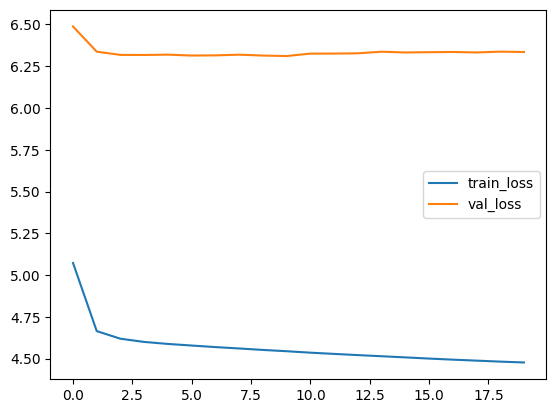

In [37]:
log.plot()

In [38]:
# compute baseline hazard
model.compute_baseline_hazards()

surv_train = model.predict_surv_df(x_train)  
surv_at_3_train = surv_train.loc[3.0]        
surv_test = model.predict_surv_df(x_test)  
surv_at_3_test = surv_test.loc[3.0]       

# get 3-year event status based on TIMETOEVENT and MORTSTAT
status_3y_train = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 0, 1)
status_3y_test = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 0, 1)

surv_f = model.predict_surv_df(x_train)
surv_at_3 = surv_f.loc[3.0].values
c_is =  c_index_classification(df_train["MORTSTAT"], surv_at_3, df_train['TIMETOEVENT'])

print(f'log-loss is: {log_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'log-loss os: {log_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'BS is: {brier_score_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'BS os: {brier_score_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'C is:, {c_is:.4f}')

log-loss is: 0.1101
log-loss os: 0.1097
BS is: 0.0293
BS os: 0.0292
C is:, 0.8945


In [39]:
# DeepS3B

In [40]:
# ================================
# Step 0: Set seeds for reproducibility
# ================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ================================
# step 2: define the network
# ================================
in_features = x_train.shape[1]
net = tt.practical.MLPVanilla(in_features, [16], 1, activation=nn.ReLU, dropout=0.2)

# ================================
# step 3: model and optimizer
# ================================

optimizer = tt.optim.Adam(lr=0.005)  
model = CoxPH(net, optimizer)

# ================================
# step 4: training setup 
# ================================

batch_size = 500
epochs = 20

# remove old checkpoint if exists
if os.path.exists('best_model.pt'):
    os.remove('best_model.pt')

# ================================
# step 5: fit the model        
# ================================

callbacks = [EarlyStopping(patience=10, file_path=None)]
log = model.fit(x_train, y_train, batch_size, epochs, val_data=(x_val, y_val), shuffle=False, callbacks=callbacks)

0:	[0s / 0s],		train_loss: 4.8367,	val_loss: 6.3330
1:	[0s / 1s],		train_loss: 4.6781,	val_loss: 6.3012
2:	[0s / 1s],		train_loss: 4.6470,	val_loss: 6.3039
3:	[0s / 2s],		train_loss: 4.6372,	val_loss: 6.3011
4:	[0s / 2s],		train_loss: 4.6199,	val_loss: 6.2876
5:	[0s / 2s],		train_loss: 4.6049,	val_loss: 6.2716
6:	[0s / 3s],		train_loss: 4.5949,	val_loss: 6.2815
7:	[0s / 3s],		train_loss: 4.5972,	val_loss: 6.2731
8:	[0s / 4s],		train_loss: 4.5953,	val_loss: 6.2955
9:	[0s / 4s],		train_loss: 4.5930,	val_loss: 6.2747
10:	[0s / 5s],		train_loss: 4.5927,	val_loss: 6.2811
11:	[0s / 5s],		train_loss: 4.5802,	val_loss: 6.2712
12:	[0s / 5s],		train_loss: 4.5823,	val_loss: 6.2822
13:	[0s / 6s],		train_loss: 4.5798,	val_loss: 6.2895
14:	[0s / 6s],		train_loss: 4.5686,	val_loss: 6.2597
15:	[0s / 7s],		train_loss: 4.5712,	val_loss: 6.2684
16:	[0s / 7s],		train_loss: 4.5737,	val_loss: 6.2521
17:	[0s / 7s],		train_loss: 4.5723,	val_loss: 6.2917
18:	[0s / 8s],		train_loss: 4.5604,	val_loss: 6.2636
19:

<Axes: >

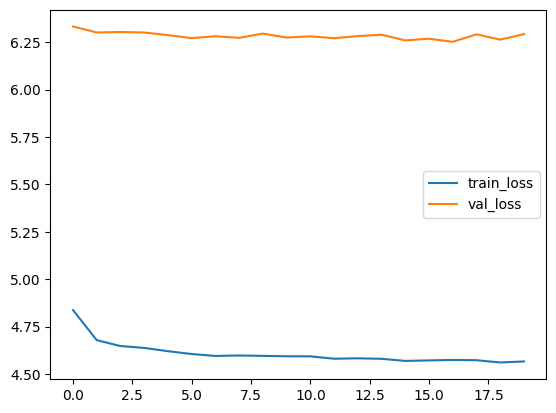

In [41]:
log.plot()

In [42]:
# compute baseline hazard
model.compute_baseline_hazards()

surv_train = model.predict_surv_df(x_train)  
surv_at_3_train = surv_train.loc[3.0]        
surv_test = model.predict_surv_df(x_test)  
surv_at_3_test = surv_test.loc[3.0]       

# get 3-year event status based on TIMETOEVENT and MORTSTAT
status_3y_train = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 0, 1)
status_3y_test = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 0, 1)

surv_f = model.predict_surv_df(x_train)
surv_at_3 = surv_f.loc[3.0].values
c_is =  c_index_classification(df_train["MORTSTAT"], surv_at_3, df_train['TIMETOEVENT'])

print(f'log-loss is: {log_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'log-loss os: {log_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'BS is: {brier_score_loss(status_3y_train, surv_at_3_train):.4f}')
print(f'BS os: {brier_score_loss(status_3y_test, surv_at_3_test):.4f}')
print(f'C is:, {c_is:.4f}')

log-loss is: 0.1102
log-loss os: 0.1094
BS is: 0.0293
BS os: 0.0292
C is:, 0.8952
